# Playing with derived distributions

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/derived_distributions.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-29*

## Learning objectives

- Understand what a **derived distribution** is: the distribution of a random variable built as a function of other random variables.
- Use **Monte-Carlo sampling** to approximate a derived distribution without any analytic derivation.
- See how a linear combination ($M = X + Y$) and a nonlinear one ($M = X + Y^2$) reshape the result.

---

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# One RNG for the whole notebook keeps the sampling reproducible.
SEED = 655
rng = np.random.default_rng(SEED)

## The idea

Often we know the distributions of some random variables and want the distribution of a *function* of them — a **derived distribution**. Working that out analytically can be painful, but it is easy to approximate: draw a large sample of each input, apply the function sample-by-sample, and histogram the result.

Here the two inputs are a normal $X$ and a uniform $Y$. The constants below set their parameters.

In [2]:
mu_X = -1
sigma_X = 0.5
lower_Y = 3
upper_Y = 8

## A sum: $M = X + Y$

First the simplest combination, the sum of the two variables. With a million samples the histograms are smooth enough to read as densities.

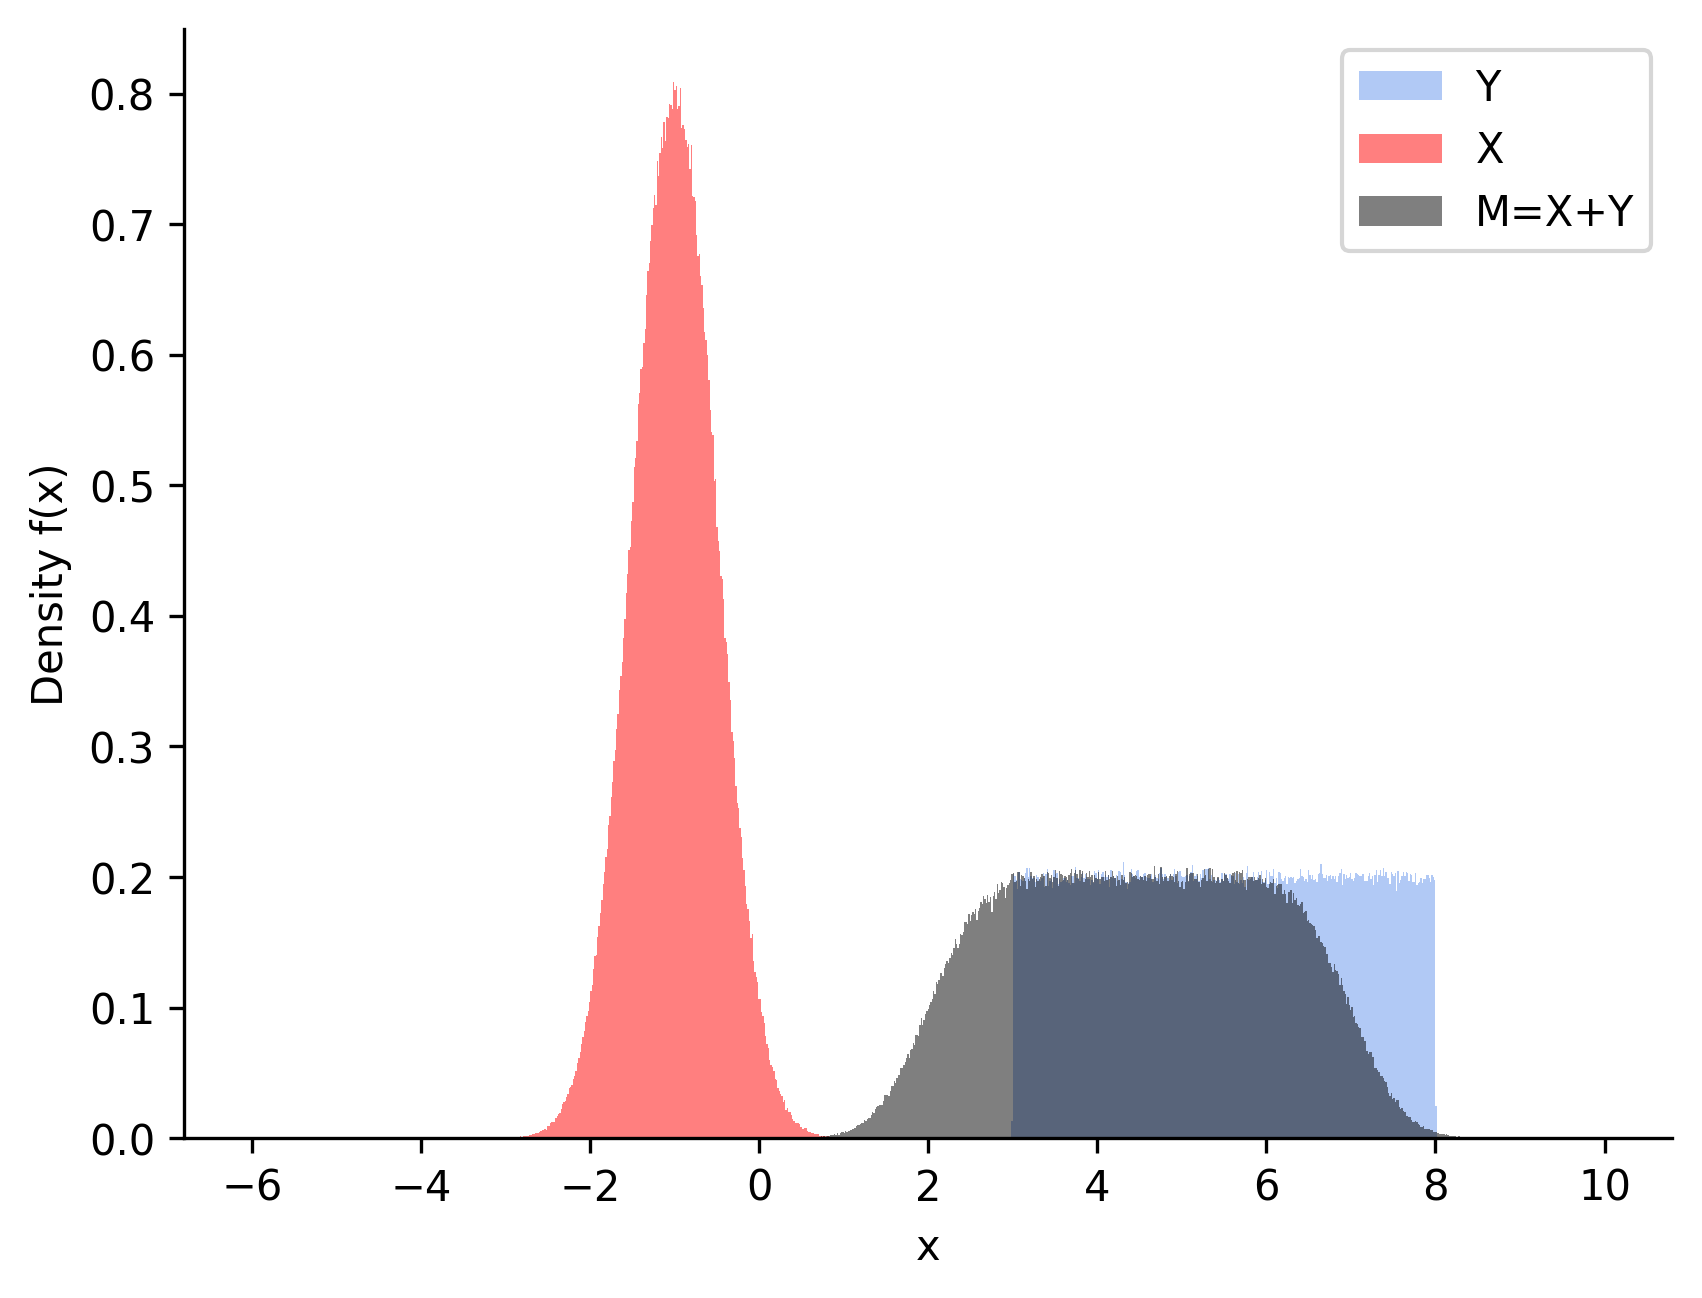

In [3]:
N = 1_000_000
X = stats.norm.rvs(loc=mu_X, scale=sigma_X, size=N, random_state=rng)
Y = stats.uniform.rvs(loc=lower_Y, scale=upper_Y - lower_Y, size=N, random_state=rng)
M = X + Y

x_bins = np.linspace(-6.0, 10, 1_000)
plt.figure(dpi=300)
plt.hist(Y, bins=x_bins, density=True, color="cornflowerblue", alpha=0.5, label="Y")
plt.hist(X, bins=x_bins, density=True, color="red", alpha=0.5, label="X")
plt.hist(M, bins=x_bins, density=True, color="black", alpha=0.5, label="M=X+Y")
plt.legend()
plt.xlabel("x")
plt.ylabel("Density f(x)")

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.show()

## Something crazier: $M = X + Y^2$

Now square the uniform variable before adding it. Squaring stretches the larger values of $Y$ much farther than the smaller ones, so the derived distribution of $M$ spreads out and becomes strongly skewed — something that would be tedious to derive by hand but falls right out of sampling.

/home/user/nbenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


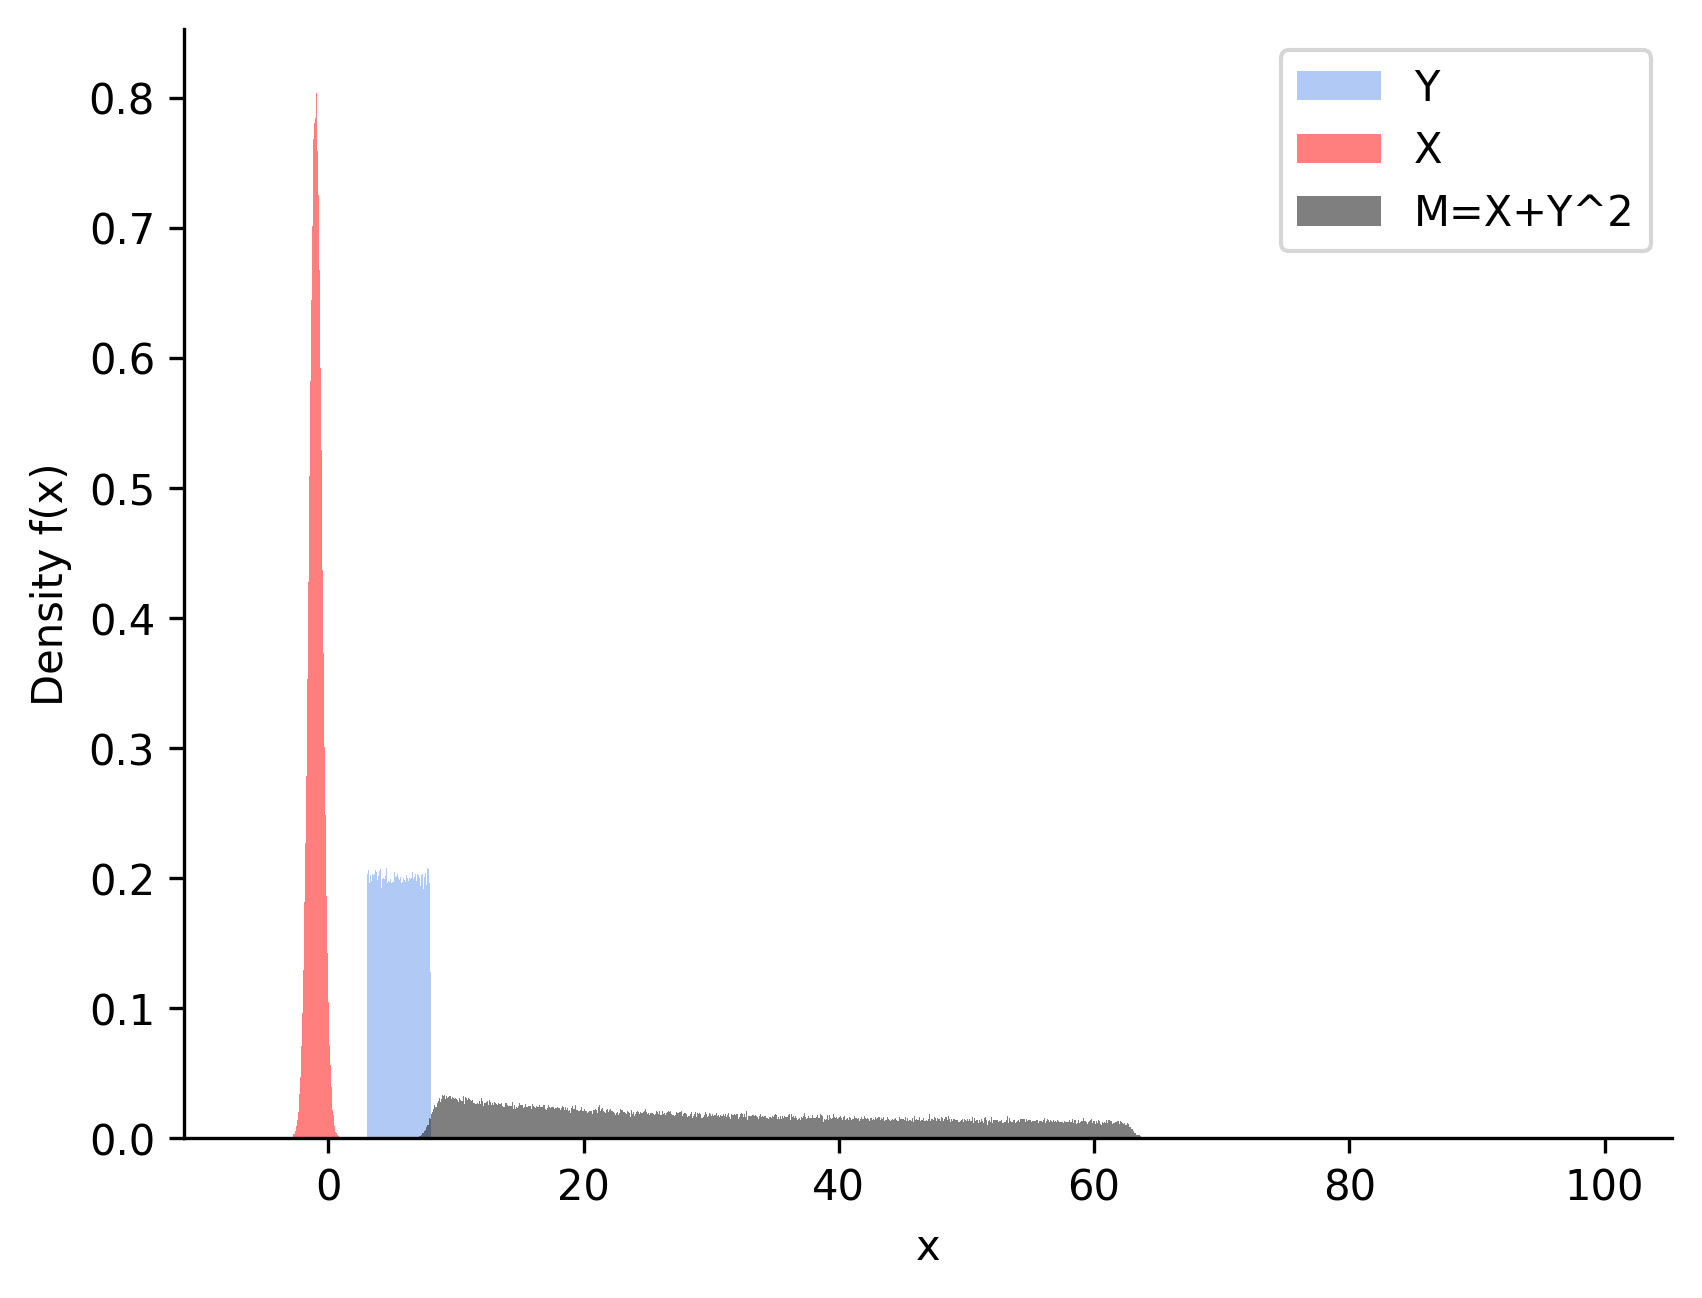

In [4]:
N = 1_000_000
X = stats.norm.rvs(loc=mu_X, scale=sigma_X, size=N, random_state=rng)
Y = stats.uniform.rvs(loc=lower_Y, scale=upper_Y - lower_Y, size=N, random_state=rng)
M = X + Y**2

x_bins = np.linspace(-6.0, 100, 10_000)
plt.figure(dpi=300)
plt.hist(Y, bins=x_bins, density=True, color="cornflowerblue", alpha=0.5, label="Y")
plt.hist(X, bins=x_bins, density=True, color="red", alpha=0.5, label="X")
plt.hist(M, bins=x_bins, density=True, color="black", alpha=0.5, label="M=X+Y^2")
plt.legend()
plt.xlabel("x")
plt.ylabel("Density f(x)")

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.show()

## Wrap-up

Monte-Carlo sampling let us read off the distribution of a derived variable just by histogramming transformed samples — no change-of-variables calculus required. The sum $X + Y$ stays compact, while the nonlinear $X + Y^2$ produces a wide, skewed distribution.